In [ ]:
!pip install -q transformers==4.57.1 accelerate torch torchvision einops "pillow==11.1.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 118.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 116.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 86.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [ ]:
!pip install -U bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 10.9 MB/s eta 0:00:00


In [ ]:
import transformers, torch, PIL
print("transformers:", transformers.__version__)
print("CUDA:", torch.cuda.is_available())
print("pillow:", PIL.__version__)
from PIL import ImageDraw  # doit s'importer sans erreur
print("PIL ImageDraw OK")

transformers: 4.57.1
CUDA: True
pillow: 11.1.0
PIL ImageDraw OK


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Abbeville-16_10__8.jpg to Abbeville-16_10__8.jpg
Saving thesau_angl.json to thesau_angl (1).json


95 termes chargés depuis le thésaurus.


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]


Réponse brute (détection) :
balcony, balustrade, capital, column, cornice, door, door/window frame, dormer window, entablature, fluted column, gargoyle, glass, grille, jamb, lintel, mullion, pediment, pilaster, pointed arch, roof, sculpture, shutter, window

Mots validés (présents dans le thésaurus) :
['balcony', 'balustrade', 'capital', 'column', 'cornice', 'door', 'door/window frame', 'dormer window', 'entablature', 'gargoyle', 'glass', 'grille', 'jamb', 'lintel', 'mullion', 'pediment', 'pilaster', 'pointed arch', 'sculpture', 'shutter', 'window']

Mots proposés hors thésaurus (ignorés) :
['fluted column', 'roof']

[balcony] réponse brute : <points coords="1 1 124 454 2 142 644 3 522 424 4 522 624 5 874 459 6 892 654">balcony.</points>
[balcony] points extraits (pixels) : [(167.772, 957.486), (192.12599999999998, 1358.1960000000001), (706.2660000000001, 894.216), (706.2660000000001, 1316.016), (1182.522, 968.0310000000001), (1206.876, 1379.286)]

[balustrade] réponse brute : <points

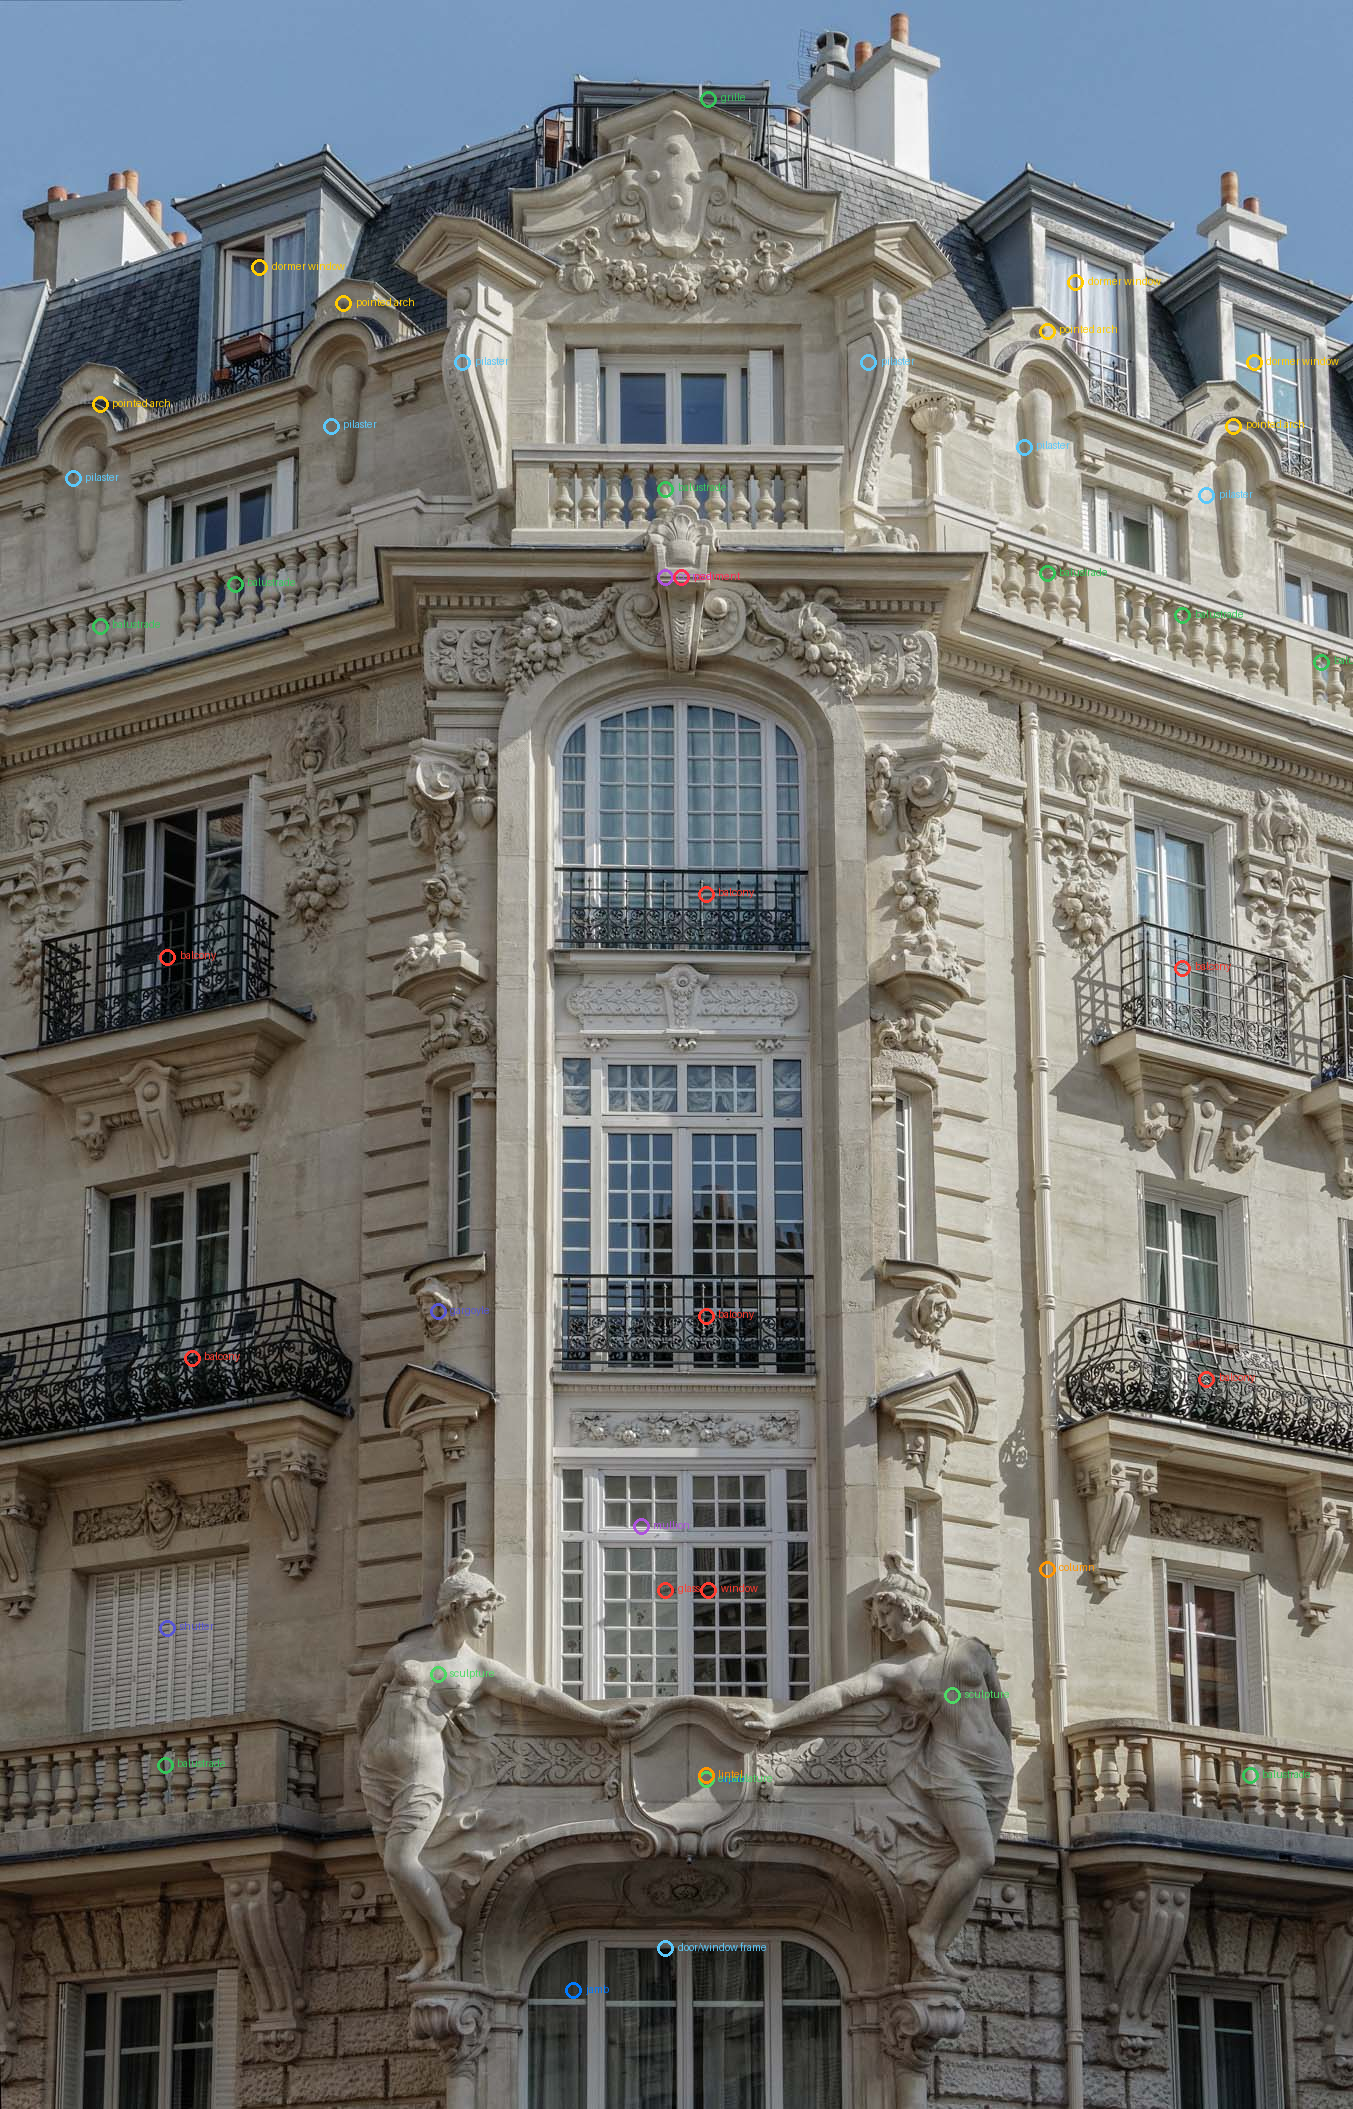


Résultats texte sauvegardés : Abbeville_16_molmo_results.txt


In [ ]:
"""
Molmo2-8B : détection de mots-clés contrôlés (thésaurus) + localisation (pointing) sur une image.


Setup recommandé (une seule fois, dans un notebook Colab tout neuf, GPU T4 ou mieux) :
    !pip install -q transformers==4.57.1 accelerate torch torchvision einops pillow
Puis Runtime > Restart session avant d'exécuter ce script.
"""

import json
import re
from PIL import Image, ImageDraw, ImageFont
from transformers import AutoProcessor, AutoModelForImageTextToText
import torch

# ----------------------------------------------------------------------
# Config
# ----------------------------------------------------------------------
IMAGE_PATH = "Abbeville-16_10__8.jpg"
THESAURUS_PATH = "thesau_angl.json"
MODEL_ID = "allenai/Molmo2-8B"
MAX_NEW_TOKENS = 448
OUTPUT_IMAGE_PATH = "Abbeville_16_molmo_annotated.jpg"
OUTPUT_TXT_PATH = "Abbeville_16_molmo_results.txt"

TERM_FIELD = "Term_angl"  # thésaurus en anglais ; utilise "Term_TMS" pour la version française

# ----------------------------------------------------------------------
# 1. Chargement du thésaurus
# ----------------------------------------------------------------------
with open(THESAURUS_PATH, "r", encoding="utf-8") as f:
    thesaurus_raw = json.load(f)

# Structure : liste plate de fiches, chacune avec un champ "cluster" (catégorie)
# et un champ TERM_FIELD contenant le terme.
words = []
term_to_category = {}
if isinstance(thesaurus_raw, list):
    for fiche in thesaurus_raw:
        if isinstance(fiche, dict) and TERM_FIELD in fiche and isinstance(fiche[TERM_FIELD], str):
            term = fiche[TERM_FIELD].strip()
            if term:
                words.append(term)
                term_to_category[term.lower()] = fiche.get("cluster", "")
else:
    raise ValueError("Structure inattendue : une liste de fiches était attendue.")

words = sorted(set(words))
print(f"{len(words)} termes chargés depuis le thésaurus.")

# ----------------------------------------------------------------------
# 2. Chargement du modèle
# ----------------------------------------------------------------------
from transformers import BitsAndBytesConfig

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    llm_int8_skip_modules=["vision_backbone"],  # garde l'encodeur d'image en bfloat16
)

processor = AutoProcessor.from_pretrained(
    MODEL_ID, trust_remote_code=True, dtype=torch.bfloat16, device_map="auto"
)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    quantization_config=quant_config,
    dtype=torch.bfloat16,
    device_map="auto",
)

image = Image.open(IMAGE_PATH).convert("RGB")


def ask_molmo(prompt_text, image):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt_text},
                {"type": "image", "image": image},
            ],
        }
    ]
    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.inference_mode():
        generated_ids = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)
    generated_tokens = generated_ids[0, inputs["input_ids"].size(1):]
    return processor.tokenizer.decode(generated_tokens, skip_special_tokens=True)


# ----------------------------------------------------------------------
# 3. Étape 1 : détection des mots présents (vocabulaire contrôlé)
# ----------------------------------------------------------------------
word_list_str = ", ".join(words)
detection_prompt = (
    "Here is a controlled list of keywords (thesaurus): "
    f"[{word_list_str}].\n\n"
    "Carefully analyze the provided image and identify ONLY the elements "
    "from this list that are actually visible in the image.\n"
    "Strict constraints:\n"
    "- Only use words present in the list, copied exactly as given.\n"
    "- Do not invent any word outside the list.\n"
    "- Do not give any explanation, no sentences.\n"
    "- Answer only as a comma-separated list."
)

raw_detection = ask_molmo(detection_prompt, image)
print("\nRéponse brute (détection) :")
print(raw_detection)

candidates = [w.strip(" .") for w in re.split(r"[,;\n]", raw_detection) if w.strip()]
words_lower = {w.lower(): w for w in words}
validated = [words_lower[c.lower()] for c in candidates if c.lower() in words_lower]
rejected = [c for c in candidates if c.lower() not in words_lower]

print("\nMots validés (présents dans le thésaurus) :")
print(validated)
if rejected:
    print("\nMots proposés hors thésaurus (ignorés) :")
    print(rejected)

# ----------------------------------------------------------------------
# 4. Étape 2 : pointing — localisation de chaque mot validé
# ----------------------------------------------------------------------
# Format de sortie de Molmo2 pour le pointing : coordonnées encodées dans un
# tag <points coords="..."/> avec des valeurs sur une échelle 0-1000, à l'échelle
# de l'image (pas des pixels directement, d'où la conversion ci-dessous).
COORD_REGEX = re.compile(r"<(?:points|tracks).*? coords=\"([0-9\t:;, .]+)\"/?>")
FRAME_REGEX = re.compile(r"(?:^|\t|:|,|;)([0-9\.]+) ([0-9\. ]+)")
POINTS_REGEX = re.compile(r"([0-9]+) ([0-9]{3,4}) ([0-9]{3,4})")


def extract_points(text, image_w, image_h):
    results = []
    for coord in COORD_REGEX.finditer(text):
        for point_grp in FRAME_REGEX.finditer(coord.group(1)):
            for m in POINTS_REGEX.finditer(point_grp.group(2)):
                _, x, y = m.groups()
                px = float(x) / 1000 * image_w
                py = float(y) / 1000 * image_h
                if 0 <= px <= image_w and 0 <= py <= image_h:
                    results.append((px, py))
    return results


term_points = {}  # terme -> liste de (x, y) en pixels

for term in validated:
    point_prompt = f"Point to the {term}."  # déjà en anglais, cohérent avec le thésaurus
    raw_points = ask_molmo(point_prompt, image)
    pts = extract_points(raw_points, image.width, image.height)
    term_points[term] = pts
    print(f"\n[{term}] réponse brute : {raw_points}")
    print(f"[{term}] points extraits (pixels) : {pts}")

# ----------------------------------------------------------------------
# 5. Rendu de l'image annotée
# ----------------------------------------------------------------------
annotated = image.copy()
draw = ImageDraw.Draw(annotated)

# palette simple, une couleur par terme (répétée si plus de termes que de couleurs)
palette = [
    "#FF3B30", "#34C759", "#007AFF", "#FF9500", "#AF52DE",
    "#FF2D55", "#5AC8FA", "#FFCC00", "#4CD964", "#5856D6",
]

try:
    font = ImageFont.truetype("DejaVuSans-Bold.ttf", 22)
except Exception:
    font = ImageFont.load_default()

for i, (term, pts) in enumerate(term_points.items()):
    color = palette[i % len(palette)]
    for (x, y) in pts:
        r = 8
        draw.ellipse([x - r, y - r, x + r, y + r], outline=color, width=3)
        draw.text((x + r + 4, y - r), term, fill=color, font=font)

annotated.save(OUTPUT_IMAGE_PATH)
print(f"\nImage annotée sauvegardée : {OUTPUT_IMAGE_PATH}")

# Affichage inline si dans un notebook Colab/Jupyter
try:
    from IPython.display import display
    display(annotated)
except ImportError:
    pass


    # ----------------------------------------------------------------------
# 6. Sauvegarde des résultats texte
# ----------------------------------------------------------------------

with open(OUTPUT_TXT_PATH, "w", encoding="utf-8") as f:
    f.write(f"Image : {IMAGE_PATH}\n")
    f.write(f"Modèle : {MOLMO_MODEL_ID if 'MOLMO_MODEL_ID' in dir() else MODEL_ID}\n")
    f.write(f"Thésaurus : {THESAURUS_PATH} ({len(words)} termes)\n\n")

    f.write("=== Réponse brute (détection) ===\n")
    f.write(raw_detection.strip() + "\n\n")

    f.write("=== Mots validés (présents dans le thésaurus) ===\n")
    f.write(", ".join(validated) + "\n\n")

    if rejected:
        f.write("=== Mots proposés hors thésaurus (ignorés) ===\n")
        f.write(", ".join(rejected) + "\n\n")

    f.write("=== Points par terme (coordonnées en pixels) ===\n")
    for term, pts in term_points.items():
        pts_str = "; ".join(f"({x:.1f}, {y:.1f})" for x, y in pts)
        f.write(f"{term}: {pts_str if pts_str else '(aucun point)'}\n")

print(f"\nRésultats texte sauvegardés : {OUTPUT_TXT_PATH}")